In [45]:
import pandas as pd
import pickle
import os
import numpy as np

In [46]:
current_directory = os.getcwd()
cwd = os.path.dirname(current_directory)
folders = ["Unconstrained model", "Constrained model", "FICNN model"]

In [47]:
def read_pickle(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

In [48]:
history_dict = {}
for folder in folders:
    history_path = os.path.join(cwd, "NN length models", folder)
    history_pickle = read_pickle(os.path.join(history_path, "history_dict.pickle"))
    history_pickle_6 = read_pickle(os.path.join(history_path, "history_dict_6.pickle"))
    history_dict[folder] = {**history_pickle, **history_pickle_6}
history_dict

{'Unconstrained model': {'1_layer': <keras.src.callbacks.history.History at 0x1bf85f09be0>,
  '2_layer': <keras.src.callbacks.history.History at 0x1bf87137ef0>,
  '4_layer': <keras.src.callbacks.history.History at 0x1bf85e64260>,
  '5_layer': <keras.src.callbacks.history.History at 0x1bf85cbdaf0>,
  '6_layer': <keras.src.callbacks.history.History at 0x1bf875315b0>},
 'Constrained model': {'1_layer': <keras.src.callbacks.history.History at 0x1bf85f0a7e0>,
  '2_layer': <keras.src.callbacks.history.History at 0x1bf859c9700>,
  '4_layer': <keras.src.callbacks.history.History at 0x1bf85977fb0>,
  '5_layer': <keras.src.callbacks.history.History at 0x1bf8591fa10>,
  '6_layer': <keras.src.callbacks.history.History at 0x1bf85a3ea20>},
 'FICNN model': {'1_layer': <keras.src.callbacks.history.History at 0x1bf85cbe090>,
  '2_layer': <keras.src.callbacks.history.History at 0x1bf8517bb00>,
  '4_layer': <keras.src.callbacks.history.History at 0x1bf85f31bb0>,
  '5_layer': <keras.src.callbacks.history.

In [49]:
from matplotlib import pyplot as plt

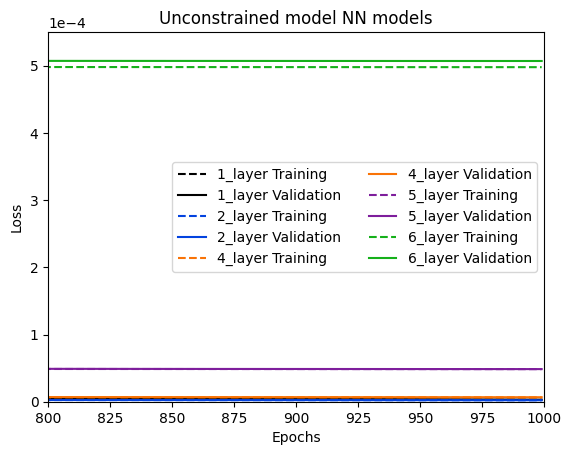

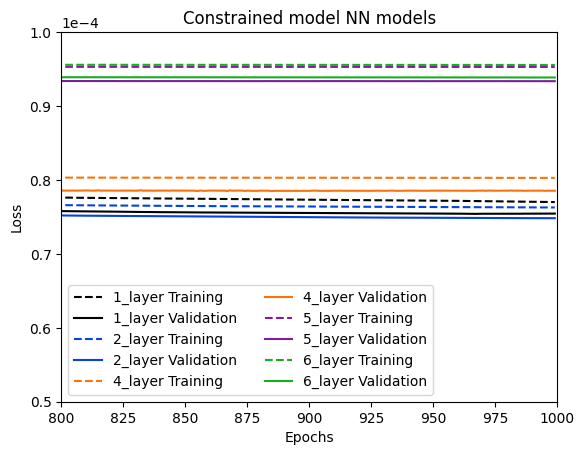

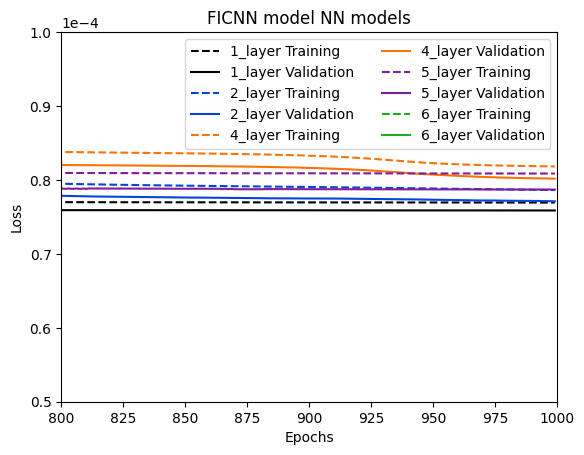

In [50]:
color_names = ["black", "blue", "orange", "purple", "green", "red"]
colors = ["xkcd:"+color_name for color_name in color_names]
for idx, (folder, histories) in enumerate(history_dict.items()):
    for i, (key, history) in enumerate(histories.items()):
        plt.plot(history.history['loss'], label=key+" Training", linestyle="--", color=colors[i])
        plt.plot(history.history['val_loss'], label=key+ " Validation", color=colors[i])

    plt.ticklabel_format(axis='y', style='sci', scilimits=(-4, -4))
    plt.title(folder + " NN models")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xlim([800, 1000])
    if idx == 0:
        plt.ylim([0, 0.00055])
    else:
        plt.ylim([0.00005, 0.0001])
    plt.legend(ncols=2)
    plt.show()

In [51]:
rmse_dict = {}

for idx, (folder, histories) in enumerate(history_dict.items()):
    rmse_dict[folder] = {}
    for i, (key, history) in enumerate(histories.items()):
        rmse = history.history["loss"][-1]**0.5 * 741.868
        key_val = key.split("_")[0]
        rmse_dict[folder][key_val] = rmse

In [52]:
rmse_dict

{'Unconstrained model': {'1': 1.2844937265351333,
  '2': 1.0848383930215522,
  '4': 1.8733912757150653,
  '5': 5.165880761132373,
  '6': 16.552989157327012},
 'Constrained model': {'1': 6.5103430952420105,
  '2': 6.479306033748008,
  '4': 6.647101710131689,
  '5': 7.24199514481702,
  '6': 7.252067850246198},
 'FICNN model': {'1': 6.507500445442128,
  '2': 6.578512895212937,
  '4': 6.7109574684339375,
  '5': 6.671471070294969,
  '6': 8.62688541406547}}

In [53]:
def get_expected_rmse(row):
    model = row['model']
    width = row['length']
    return rmse_dict[model][width]

In [54]:
summary_tables = read_pickle("length_summmary_tables.pickle")
# summary_tables = summary_tables[summary_tables["infeasible"] == False]
# print(summary_tables)
rmse_table = (summary_tables.groupby(["length", "methodology"])["mean_square_error"].mean()) **0.5
rmse_table = rmse_table.reset_index()
rmse_table['model'] = np.where(
    rmse_table['methodology'] == 'ICNN 1',
    'Constrained model',
    np.where(
        rmse_table['methodology'] == 'ICNN 2',
        'FICNN model',
        'Unconstrained model'
    )
)
rmse_table["expected_rmse"] = rmse_table.apply(get_expected_rmse, axis = 1)

In [55]:
df = rmse_table
df.loc[df["methodology"] == "ICNN 2", "methodology"] = "ICNN"

In [59]:
rmse_table

,length,methodology,mean_square_error,model,expected_rmse
0,1,Gurobi ML,1.60327,Unconstrained model,1.284494
1,1,ICNN 1,4.977795,Constrained model,6.510343
2,1,ICNN,5.199311,FICNN model,6.507500
3,1,PCAR,15.792512,Unconstrained model,1.284494
4,1,PCTAR,15.792512,Unconstrained model,1.284494
5,2,Gurobi ML,2.732642,Unconstrained model,1.084838
6,2,ICNN 1,5.256596,Constrained model,6.479306
7,2,ICNN,5.415495,FICNN model,6.578513
8,2,PCAR,29.229667,Unconstrained model,1.084838
9,2,PCTAR,29.229667,Unconstrained model,1.084838


In [63]:
colors = ['xkcd:purple', 'xkcd:orange', 'xkcd:blue', 'xkcd:red', "xkcd:dark gray"]
plot_order = ["Gurobi ML", "PCTAR", "PCAR",
              # "ICNN 1", 
              "ICNN"]

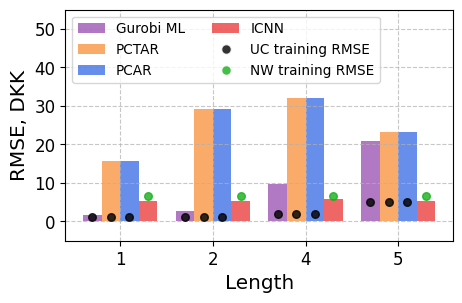

In [64]:
# Plotting
plt.figure(figsize=(5, 3))

# Set bar width and position
bar_width = 1/5
x_positions = np.arange(len(rmse_table['length'].unique()))
handles = []
# Create separate bars for each methodology
for i, methodology in enumerate(plot_order):
    if methodology == "ICNN":
        color_dot = "xkcd:green"
    else:
        color_dot = "xkcd:black"
    subset = rmse_table[(rmse_table['methodology'] == methodology) & (rmse_table["length"] != '6')]
    bar_positions = x_positions + ((i - 1) * bar_width)  # Shift bars for each methodology
    bars = plt.bar(bar_positions[:-1], subset['mean_square_error'], width=bar_width, label=methodology, alpha=0.6, zorder=1, color=colors[i])
    handles.append(bars)

    # Annotate expected RMSE values on top of each bar as dots
    for bar, expected_rmse in zip(bars, subset['expected_rmse']):
        yval = bar.get_height()
        plt.scatter(bar.get_x() + bar.get_width() / 2, expected_rmse, color=color_dot, s=30, zorder=8, alpha=0.8)  # Red dots above bars
# Adding labels and title
plt.xlabel('Length', fontsize="x-large")
plt.ylabel('RMSE, DKK', fontsize="x-large")
plt.xticks(x_positions[:-1] + bar_width / 2, rmse_table['length'].unique()[:-1], fontsize="large")  # Center the x-ticks
plt.yticks(fontsize="large")
plt.ylim([-5, 55])

# Add a custom legend for expected RMSE levels
expected_rmse_patch_1 = plt.Line2D([0], [0], marker='o', color='w', label='UC training RMSE',
                                   markerfacecolor='xkcd:black', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_1)
expected_rmse_patch_2 = plt.Line2D([0], [0], marker='o', color='w', label='NW training RMSE',
                                   markerfacecolor='xkcd:green', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_2)
plt.legend(ncols=2, handles = handles, loc="upper left", fontsize=9.8)
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.savefig(os.path.join(cwd, "images", "length_rmse_plot.pdf"), bbox_inches="tight")
plt.show()

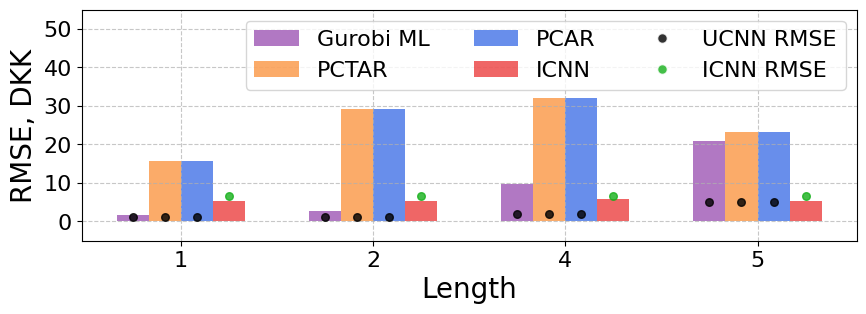

In [70]:
# Plotting
plt.figure(figsize=(10, 3))

# Set bar width and position
bar_width = 1/6
x_positions = np.arange(len(rmse_table['length'].unique()))
handles = []
# Create separate bars for each methodology
for i, methodology in enumerate(plot_order):
    if methodology == "ICNN":
        color_dot = "xkcd:green"
    # elif methodology == "ICNN 2":
    #     color_dot = "xkcd:gold"
    else:
        color_dot = "xkcd:black"
    
    new_label = methodology    
    subset = rmse_table[(rmse_table['methodology'] == methodology) & (rmse_table["length"] != '6')]
    bar_positions = x_positions + ((i - 1) * bar_width)  # Shift bars for each methodology
    bars = plt.bar(bar_positions[:-1], subset['mean_square_error'], width=bar_width, label=new_label, alpha=0.6, zorder=1, color=colors[i])
    handles.append(bars)

    # Annotate expected RMSE values on top of each bar as dots
    for bar, expected_rmse in zip(bars, subset['expected_rmse']):
        yval = bar.get_height()
        plt.scatter(bar.get_x() + bar.get_width() / 2, expected_rmse, color=color_dot, s=30, zorder=8, alpha=0.8)  # Red dots above bars
# Adding labels and title
plt.xlabel('Length', fontsize=20)
plt.ylabel('RMSE, DKK', fontsize=20)
plt.xticks(x_positions[:-1] + bar_width / 2, rmse_table['length'].unique()[:-1], fontsize=16)  # Center the x-ticks
plt.yticks(fontsize=16)
plt.ylim([-5, 55])

# Add a custom legend for expected RMSE levels
expected_rmse_patch_1 = plt.Line2D([0], [0], marker='o', color='w', label='UCNN RMSE',
                                   markerfacecolor='xkcd:black', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_1)
expected_rmse_patch_2 = plt.Line2D([0], [0], marker='o', color='w', label='ICNN RMSE',
                                   markerfacecolor='xkcd:green', markersize=7, alpha=0.8)
handles.append(expected_rmse_patch_2)
# expected_rmse_patch_3 = plt.Line2D([0], [0], marker='o', color='w', label='ICNN 2 NN RMSE',
#                                    markerfacecolor='xkcd:gold', markersize=7, alpha=0.8)
# handles.append(expected_rmse_patch_3)
plt.legend(ncols=3, handles = handles, loc="upper right", fontsize=16)
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.savefig(os.path.join(cwd, "images", "length_rmse_plot_v2.pdf"), bbox_inches="tight")
plt.show()

In [66]:
mask = (summary_tables.length == '4') & (summary_tables.methodology == "Gurobi ML")
summary_tables[mask]

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,length,methodology,scenario_type,case,infeasible
20,101.323546,3.428635,66.582,457.531,0.9,True,4,Gurobi ML,Low_prices,0,False
21,440.027977,400.02958,18.369,138.672,0.9,True,4,Gurobi ML,Low_prices,1,False
22,480.463249,7.689289,19.647,158.578,0.9,True,4,Gurobi ML,Low_prices,2,False
23,167.153372,530.28691,293.145,2204.828,0.8,True,4,Gurobi ML,Low_prices,3,False
24,183.650494,6.612824,18.723,151.547,0.9,True,4,Gurobi ML,Low_prices,4,False
25,561.002683,2.767336,19.748,146.734,0.5,True,4,Gurobi ML,Low_prices,5,False
26,33.202809,3.402563,21.904,179.0,0.9,True,4,Gurobi ML,Low_prices,6,False
27,52.768175,1.70999,24.735,210.688,0.2,True,4,Gurobi ML,Low_prices,7,False
28,43.153648,3.417935,21.8,184.141,0.0,True,4,Gurobi ML,Low_prices,8,False
29,28.903279,1.402751,27.92,254.406,0.0,True,4,Gurobi ML,Low_prices,9,False


In [40]:
summary_tables[mask].mean_square_error.sum()

960.7478144616805

In [41]:
3.824**0.5

1.9555050498528506